--- BINANCE P2P REPORT [14:46:05] ---
AVERAGE PRICE: 465.20 VES

TOP 5 CURRENT OFFERS:


,Advertiser,Price
0,User-a45bd,450.0
1,ELCHINOSOF25,468.0
2,PedroEspinoza,469.0
3,MzVentasCripto,469.5
4,User-1eded,469.5


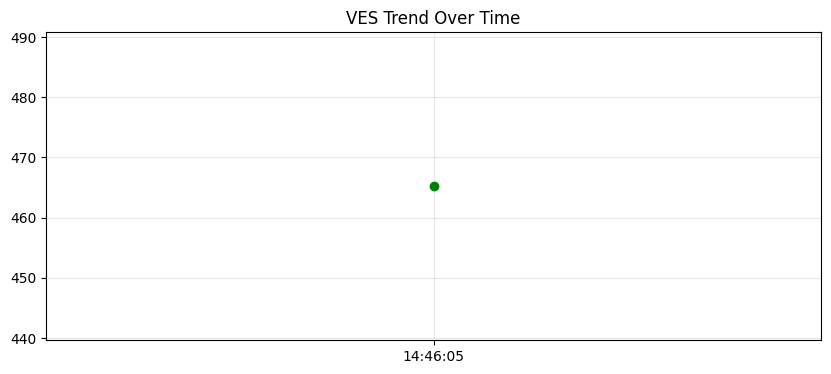

In [ ]:
import papermill as pm
import scrapbook as sb
import matplotlib.pyplot as plt
import pandas as pd
import time
from datetime import datetime
from IPython.display import clear_output, display

# Settings
fiat_currency = "VES"
interval = 1800 
results_list = []
time_labels = []

try:
    while True:
        timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")
        output_path = f"entry_{timestamp_str}.ipynb"
        
        # 1. Execute
        pm.execute_notebook(r'binance_logic.ipynb.ipynb', output_path, parameters=dict(fiat=fiat_currency))
        
        # 2. Extract Data
        nb = sb.read_notebook(output_path)
        val = nb.scraps['promedio_final'].data
        offers = nb.scraps['top_5_offers'].data # The list of 5 offers
        t = nb.scraps['timestamp'].data
        
        results_list.append(val)
        time_labels.append(t)
        
        # 3. Clear and Update Dashboard
        clear_output(wait=True)
        print(f"--- BINANCE P2P REPORT [{t}] ---")
        print(f"AVERAGE PRICE: {val:,.2f} {fiat_currency}\n")
        
        # 4. Print the 5 Offers as a Pretty Table
        print("TOP 5 CURRENT OFFERS:")
        df_offers = pd.DataFrame(offers)
        display(df_offers) # This renders a nice table in Jupyter
        
        # 5. Show Trend Graph
        plt.figure(figsize=(10, 4))
        plt.plot(time_labels, results_list, marker='o', color='green')
        plt.title(f"{fiat_currency} Trend Over Time")
        plt.grid(True, alpha=0.3)
        plt.show()
        
        time.sleep(interval)

except KeyboardInterrupt:
    print("Stopped.")
    

In [ ]:
import papermill as pm
import scrapbook as sb
import pandas as pd
import matplotlib.pyplot as plt
import time
import os
from datetime import datetime
from wakepy import keep

# --- CONFIGURACIÓN ---
FIAT = "VES"
INTERVALO = 1800  # 30 minutos
CARPETA_SALIDA = "terminal_logs"
input_nb = 'binance_logic.ipynb' # Asegúrate de que el nombre sea correcto

if not os.path.exists(CARPETA_SALIDA):
    os.makedirs(CARPETA_SALIDA)

# Listas para la gráfica
results_list = []
time_labels = []
ultimo_dia = datetime.now().day

print(f"🚀 Iniciando Monitor de Binance para {FIAT}...")
print("🔔 wakepy está ACTIVO. Presiona Ctrl+C para detener.\n")

with keep.running():
    try:
        while True:
            ahora = datetime.now()
            
            # --- LÓGICA DE REINICIO DIARIO ---
            if ahora.day != ultimo_dia:
                results_list = []
                time_labels = []
                ultimo_dia = ahora.day
                print("\n[📅] Nuevo día detectado: Reiniciando datos de la gráfica.")

            timestamp_str = ahora.strftime("%Y%m%d_%H%M%S")
            output_path = f"{CARPETA_SALIDA}/log_{timestamp_str}.ipynb"
            
            # 1. Ejecutar el notebook de lógica
            pm.execute_notebook(
                input_nb, 
                output_path, 
                parameters=dict(fiat=FIAT),
                progress_bar=False 
            )
            
            # 2. Extraer datos
            nb = sb.read_notebook(output_path)
            avg = nb.scraps['promedio_final'].data
            offers = nb.scraps['top_5_offers'].data
            t = nb.scraps['timestamp'].data
            
            # Guardar para la gráfica
            results_list.append(avg)
            time_labels.append(t)
            
            # 3. Generar Gráfica (Se guarda como archivo)
            plt.figure(figsize=(10, 5))
            plt.plot(time_labels, results_list, marker='o', color='blue')
            plt.title(f"Tendencia USDT/{FIAT} - {ahora.strftime('%d/%m/%Y')}")
            plt.xticks(rotation=45)
            plt.grid(True)
            plt.tight_layout()
            plt.savefig('grafica_diaria.png') # Se sobrescribe cada 30 min
            plt.close() # Cierra la figura para no consumir memoria

            # 4. Imprimir en Terminal
            os.system('cls' if os.name == 'nt' else 'clear') 
            
            print("="*50)
            print(f" REPORTE BINANCE P2P | {t} ")
            print("="*50)
            print(f"PRECIO PROMEDIO: {avg:,.2f} {FIAT}")
            print(f"Gráfica actualizada en: grafica_diaria.png")
            print("-"*50)
            print("LAS 5 MEJORES OFERTAS:")
            
            df = pd.DataFrame(offers)
            print(df.to_string(index=False)) 
            
            print("="*50)
            print(f"Próxima actualización en 30 minutos...")
            
            time.sleep(INTERVALO)

    except KeyboardInterrupt:
        print("\n[!] Monitoreo detenido.")

Passed unknown parameter: fiat
Input notebook does not contain a cell with tag 'parameters'


🚀 Iniciando Monitor de Binance para VES...
🔔 wakepy está ACTIVO. Presiona Ctrl+C para detener.

 REPORTE BINANCE P2P | 09:00:19 
PRECIO PROMEDIO: 612.23 VES
Gráfica actualizada en: grafica_diaria.png
--------------------------------------------------
LAS 5 MEJORES OFERTAS:
        Advertiser   Price
   CRYPTO BUSINESS 611.000
   RickyRiconn_DTP 611.800
             22456 612.000
   AMEZQUITA 2025  612.000
             JFC00 612.000
       abrahamking 612.000
             InvFU 612.000
        AMAROLOGIA 612.000
  cambiosseguros_1 612.136
        SUPRA__P2P 612.137
     StephanyGaray 612.399
  Víctorfernandez1 612.400
        Cambios_JB 612.489
          fabita13 612.490
          Jean1024 612.498
        ricardoM94 612.500
     Soto_Crypto90 612.500
        GB_cambios 612.552
       Enriquelpc- 612.800
 Confianza-Cambios 612.899
Próxima actualización en 30 minutos...


Passed unknown parameter: fiat
Input notebook does not contain a cell with tag 'parameters'


 REPORTE BINANCE P2P | 09:30:28 
PRECIO PROMEDIO: 609.84 VES
Gráfica actualizada en: grafica_diaria.png
--------------------------------------------------
LAS 5 MEJORES OFERTAS:
       Advertiser   Price
      GoldSeguros 609.000
        rafaelpss 609.000
       rondon1234 609.000
      FELIPE_1994 609.700
             sjas 609.900
       gabostonks 609.980
          Luiszor 609.990
            Yes25 609.990
    BBPV Official 609.990
           Fabvsm 609.999
        hectorggc 610.000
  bitservycompany 610.000
          Crisa77 610.000
      DoggyTorres 610.000
inversionesjc2020 610.000
            InvFU 610.000
    FRANKLYNCAMPO 610.000
     Bizcochito-o 610.000
      Carlosv2821 610.100
    ExpresYRapidD 610.100
Próxima actualización en 30 minutos...


Passed unknown parameter: fiat
Input notebook does not contain a cell with tag 'parameters'


...

 REPORTE BINANCE P2P | 14:32:15 
PRECIO PROMEDIO: 614.95 VES
Gráfica actualizada en: grafica_diaria.png
--------------------------------------------------
LAS 5 MEJORES OFERTAS:
      Advertiser   Price
  Dayanajuarez28 613.000
        Neycar15 614.000
      AndressDuo 614.409
     Dark_Leader 614.500
 Kathleen Vic_D7 614.990
-__-FabioJyR-__- 614.997
        Zuly1760 614.999
      Yudith2604 614.999
   altaeconomica 614.999
        VEREDOOM 615.000
      DaGaMaDaGu 615.000
        Franmar4 615.000
         Dengar1 615.000
       CarlosXCB 615.000
          wjbm01 615.000
      Arabito777 615.000
      anthonydfl 615.500
    ExpresoPolar 615.700
      1980MANMEN 615.880
      PatriciaKG 615.930
Próxima actualización en 30 minutos...


Passed unknown parameter: fiat
Input notebook does not contain a cell with tag 'parameters'


 REPORTE BINANCE P2P | 15:02:24 
PRECIO PROMEDIO: 616.29 VES
Gráfica actualizada en: grafica_diaria.png
--------------------------------------------------
LAS 5 MEJORES OFERTAS:
         Advertiser   Price
           Zuly1760 614.999
      altaeconomica 614.999
           VEREDOOM 615.000
        Yamileduran 615.000
          Pagospeed 615.001
carpioadriangabriel 616.000
     Alisson Florez 616.000
         Italcripto 616.000
            factorX 616.350
              kront 616.500
      CONECTATECAMB 616.800
        ChangesGold 616.999
          LilDublin 617.000
      P_drm24030806 617.000
      Andysmp212003 617.000
          ELGOCHITO 617.000
        Andreishope 617.000
          Alexnor16 617.000
          YuniorZ06 617.000
         cambio-max 617.200
Próxima actualización en 30 minutos...


Passed unknown parameter: fiat
Input notebook does not contain a cell with tag 'parameters'


 REPORTE BINANCE P2P | 15:32:33 
PRECIO PROMEDIO: 618.83 VES
Gráfica actualizada en: grafica_diaria.png
--------------------------------------------------
LAS 5 MEJORES OFERTAS:
         Advertiser   Price
         User-997ba 617.890
           wizerdss 617.890
        cambiosAlex 617.950
          ReyDavid_ 618.000
     Corymar palma  618.000
          criptocol 618.000
Venta-Delta-activos 618.200
           Turco_ds 618.270
         CambiosMyE 618.997
       Bozo-Crypto  618.998
               kike 618.999
       P2P-3bdc91dd 619.000
         ComputClic 619.000
             Celiaq 619.100
         User-43b29 619.300
           HectorAG 619.499
           jandergv 619.500
           riverjom 619.990
           Anita_91 619.990
   José Carrizales  620.000
Próxima actualización en 30 minutos...
